# Bayesian logistic regression for churn prediction

In [22]:
!pip install numpy pandas matplotlib seaborn pymc arviz scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.2 MB 4.0 MB/s eta 0:00:02
   -------- ------------------------------- 1.8/8.2 MB 4.1 MB/s eta 0:00:02
   ---------- ----------------------------- 2.1/8.2 MB 2.8 MB/s eta 0:00:03
   ------------ --------------------------- 2.6/8.2 MB 2.7 MB/s eta 0:00:03
   --------------- ------------------------ 3.1/8.2 MB 2.8 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.2 MB 2.8 MB/s eta 0:00:02
   --------------------- ------------------ 4.5/8.2 MB 2.8 MB/s eta 0:00:02
   -------------------------- ------------- 5.5/8.2 MB 3.0 MB/s eta 0:00:01
   -------------------------------- ------- 6.6/8.2 MB 3.3 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.2 MB 3.3 MB/s eta 0:00:01
   ----------------------------------- 

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pymc as pm
import arviz as az

seed = 42
rng = np.random.default_rng(seed)

## 1- Problem statement
In companies that offer services (such as a mobile phone operator), customer retention is a major challenge. The churn rate refers to the percentage of customers who decide to cancel their subscription (e.g., to switch to another provider). If the company can predict which customers are likely to churn, it can take proactive steps — such as offering additional services or special deals — to retain them.

In [14]:
df = pd.read_csv("../bayessian/data/churn.csv", index_col=0)
df.head()

,Dependents,TechSupport,Contract,InternetService,CustomerID_Region,MonthlyCharges,Months,Churn
0,Yes,No,One year,Fiber optic,MIS-1,78.95,34.0,0
1,Yes,Yes,Two year,DSL,DAL-1,85.95,70.0,0
2,No,Yes,Two year,Fiber optic,SAN-1,104.00,69.0,0
3,No,No internet service,Month-to-month,No,HOU-1,20.55,5.0,0
4,Yes,Yes,Two year,Fiber optic,HOU-1,113.10,72.0,0


In [15]:
df.columns

Index(['Dependents', 'TechSupport', 'Contract', 'InternetService',
       'CustomerID_Region', 'MonthlyCharges', 'Months', 'Churn'],
      dtype='str')

In [16]:
# get the X and y variables
y = df.Churn
X = df.drop("Churn", axis=1)

In [17]:
y.value_counts()

Churn
0    100
1    100
Name: count, dtype: int64

In [18]:
X.dtypes

Dependents               str
TechSupport              str
Contract                 str
InternetService          str
CustomerID_Region        str
MonthlyCharges       float64
Months               float64
dtype: object

In [19]:
X.Contract.value_counts()

Contract
Month-to-month    133
One year           37
Two year           30
Name: count, dtype: int64

## 2. Data preprocessing

### 2.1 One-hot encoding / dummy variables
We need to pre-process the data: turn the categorical variables to binary dummy variables. This is called one-hot encoding. Here is how it goes: - for a variable like Contract which takes Month-to-Month, One year or Two year (three categories) we can transform it to a 3 binary variables:

In [25]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first')
encoded_data = encoder.fit_transform(df[["Contract"]])
encoded_data

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 67 stored elements and shape (200, 2)>

In [26]:
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_data = encoder.fit_transform(X[["Contract"]])
encoded_data[:10]

array([[1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 0.],
       [0., 1.],
       [0., 0.],
       [1., 0.],
       [1., 0.],
       [0., 0.],
       [0., 0.]])

In [27]:
encoder = OneHotEncoder(drop='first', sparse_output=False)
categorical_features = ["Dependents", "TechSupport", "Contract", "InternetService", "CustomerID_Region"]
encoded_data = encoder.fit_transform(X[categorical_features])
encoded_data[:10]

array([[1., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
        0., 0.],
       [1., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.],
       [0., 0., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        1., 0.],
       [0., 1., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
        0., 0.],
       [1., 0., 1., 0., 1., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
        0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
        0., 0.],
       [0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
        0., 0.],
       [1., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
        0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.]])

But later we will have a regression coefficient for each one of these columns, how do we know which one belongs to which ? Well we can get their names from the encoder:

In [28]:
encoder.get_feature_names_out(categorical_features)

array(['Dependents_Yes', 'TechSupport_No internet service',
       'TechSupport_Yes', 'Contract_One year', 'Contract_Two year',
       'InternetService_Fiber optic', 'InternetService_No',
       'CustomerID_Region_CHI-1', 'CustomerID_Region_DAL-1',
       'CustomerID_Region_HOU-1', 'CustomerID_Region_LAX-1',
       'CustomerID_Region_MIA-1', 'CustomerID_Region_MIS-1',
       'CustomerID_Region_NYC-1', 'CustomerID_Region_PHL-1',
       'CustomerID_Region_PHX-1', 'CustomerID_Region_SAN-1',
       'CustomerID_Region_SEA-1'], dtype=object)

### 2.2 Scaling numerical features
We also have continuous variables (numerical features): Months and MonthlyCharges. As explained in the last class, it’s important for them to have the same scale (order of magnitude) in a linear model. Scaling a variable means centering it and dividing by its standard deviation:

In [31]:
variable = X["Months"]
variable = variable - variable.mean()
variable = variable / variable.std()
variable.head()

0    0.326288
1    1.850800
2    1.808453
3   -0.901791
4    1.935495
Name: Months, dtype: float64

It is tedious to do this for each variable, the best way to do it is to use a sklearn transformer called StandardScaler:

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numeric_features = ["MonthlyCharges", "Months"]
scaled_data = scaler.fit_transform(X[numeric_features])
scaled_data[:10]

array([[ 0.37846895,  0.32710679],
       [ 0.63721955,  1.85544479],
       [ 1.30442645,  1.81299095],
       [-1.78025031, -0.90405438],
       [ 1.64080222,  1.94035245],
       [ 0.56698725, -1.03141588],
       [ 1.37835519,  0.58182979],
       [ 1.04937229,  0.66673745],
       [ 0.19734354, -0.77669288],
       [ 0.79062169, -0.73423905]])

### 2.3 Merging both in one transformer:
We can handle both categorical and numerical features in one ColumnTransformer object:

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

categorical_features = ["Dependents", "TechSupport", "Contract", "InternetService", "CustomerID_Region"]
numeric_features = ["MonthlyCharges", "Months"]

categorical_transformer = OneHotEncoder(drop="first", sparse_output=False)
numeric_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features),
        ('num', numeric_transformer, numeric_features),
    ],
)

transformed_data = preprocessor.fit_transform(X)
print(f"The shape of the transformed data is {transformed_data.shape}")

# we construct a new pandas with the column names:
column_names = preprocessor.get_feature_names_out()
transformed_df = pd.DataFrame(transformed_data, columns=column_names)
transformed_df.head()

The shape of the transformed data is (200, 20)


,cat__Dependents_Yes,cat__TechSupport_No internet service,cat__TechSupport_Yes,cat__Contract_One year,cat__Contract_Two year,cat__InternetService_Fiber optic,cat__InternetService_No,cat__CustomerID_Region_CHI-1,cat__CustomerID_Region_DAL-1,cat__CustomerID_Region_HOU-1,cat__CustomerID_Region_LAX-1,cat__CustomerID_Region_MIA-1,cat__CustomerID_Region_MIS-1,cat__CustomerID_Region_NYC-1,cat__CustomerID_Region_PHL-1,cat__CustomerID_Region_PHX-1,cat__CustomerID_Region_SAN-1,cat__CustomerID_Region_SEA-1,num__MonthlyCharges,num__Months
0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.378469,0.327107
1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.637220,1.855445
2,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.304426,1.812991
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.780250,-0.904054
4,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.640802,1.940352


### 2.4 Preprocessing and the train-test split
But when developing a machine learing model, we always follow the train-test paradigm where we split train-test data: therefore when transforming / encoding / scaling the variables we should only be using the train data. Otherwise info from the test data will be used by the model: for example, the scaling operation will use test samples to compute the mean and std. Therefore, the column transformer object should be fit on the train only, then we use the transform method on the test data:

In [34]:
from sklearn.model_selection import train_test_split

categorical_features = ["Dependents", "TechSupport", "Contract", "InternetService", "CustomerID_Region"]
numeric_features = ["MonthlyCharges", "Months"]

categorical_transformer = OneHotEncoder(drop="first", sparse_output=False)
numeric_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features),
        ('num', numeric_transformer, numeric_features),
    ],
)

X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.3, random_state=42, stratify=y)

X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

# we get the column names:
column_names = preprocessor.get_feature_names_out()

## 3. Logistic regression
We can now start doing ML models. First, we use logistic regression without regularization:

### 3.1 Without regularization


In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# we can fit the logistic regression model with no regularization:
model = LogisticRegression(penalty=None)
model.fit(X_train_processed, y_train.values)

y_train_pred = model.predict(X_train_processed)
y_test_pred = model.predict(X_test_processed)

# Evaluate the model accuracy
print(f"Training accuracy: {accuracy_score(y_train_pred, y_train):.4f}")
print(f"Test accuracy: {accuracy_score(y_test_pred, y_test):.4f}")

Training accuracy: 0.8357
Test accuracy: 0.6500


C:\Users\EQUIPO\desktop\projects\bayessian\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


We can see that the model isn’t quite good: 1. 83% accuracy on the training data means that the model isnt complex enough to predict labels it has already seen 2. 65% accuracy on the test data suggest a big difference between train and test: the models learns a bit of noise in the training data

We can extract the coefficients and visualize their values:

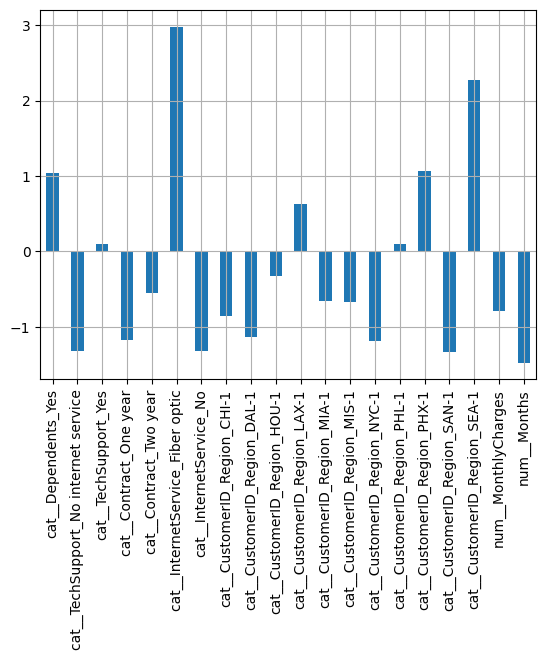

In [36]:
coef = pd.DataFrame(model.coef_, columns=column_names)
coef.T.plot(kind="bar", legend=False)
plt.grid()
plt.show()

We can extract the change in the odd-ratios and visualize their importance in percentages

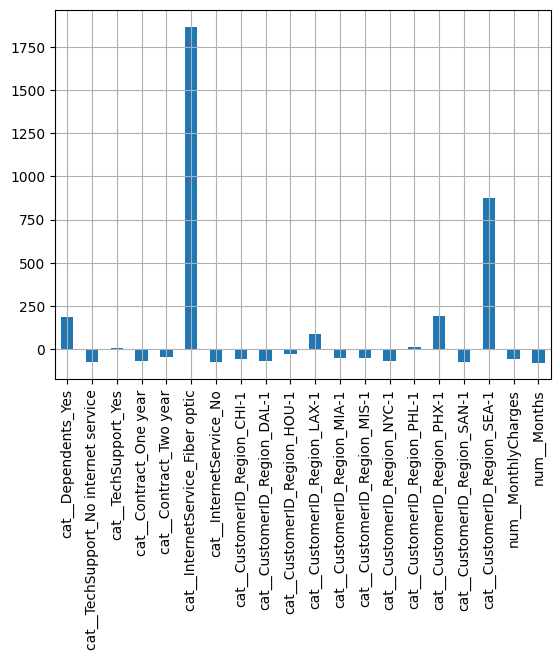

In [38]:
odds_changes = (np.exp(model.coef_) - 1) * 100
coef = pd.DataFrame(odds_changes, columns=column_names)
coef.T.plot(kind="bar", legend=False)
plt.grid()
plt.show()

In [39]:
odds_changes

array([[ 184.33978368,  -73.24588216,   10.11408019,  -69.01164118,
         -42.3604937 , 1867.04450222,  -73.24588216,  -57.30827598,
         -67.89164809,  -27.90134379,   87.71595551,  -47.99574828,
         -49.09364831,  -69.35050994,   10.37215112,  190.19346862,
         -73.42643779,  875.62186833,  -54.79865072,  -77.0485994 ]])

In [40]:
X["Months"].std(), X["MonthlyCharges"].std()

(np.float64(23.61410818827673), np.float64(27.120965039260753))

Some odd percentage changes are off-the-charts ! 1867% increase with Optic Fiber and 875% if the customer is in the region SEA-1 ! Given that the performance of the model is poor here and the coefficient values are very large it is very likely the model has learned noise: regularization is needed.

### 3.2 With L2 / L1 regularization


We can now try to improve the model by adding regularization. We can use the LogisticRegressionCV class which will automatically find the best regularization parameter for us:

In [41]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import accuracy_score

# we can fit the logistic regression model with no regularization:
model = LogisticRegressionCV(Cs=np.logspace(-3, 3, 100), penalty="l2")
model.fit(X_train_processed, y_train.values)

y_train_pred = model.predict(X_train_processed)
y_test_pred = model.predict(X_test_processed)

# Evaluate the model accuracy
print(f"Training accuracy: {accuracy_score(y_train_pred, y_train):.4f}")
print(f"Test accuracy: {accuracy_score(y_test_pred, y_test):.4f}")

C:\Users\EQUIPO\desktop\projects\bayessian\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
C:\Users\EQUIPO\desktop\projects\bayessian\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:2123: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' and 'Cs' instead. Use l1_ratios=(0,) instead of penalty='l2', l1_ratios=(1,) instead of penalty='l1', l1_ratios set to floats between 0 and 1 instead of penalty='elasticnet', and Cs=(np.inf,) instead of penalty=None.
  warnings.warn(
C:\Users\EQUIPO\desktop\projects\bayessian\venv\Lib\site-packages\sklearn\linear_model\_logistic.py

Training accuracy: 0.7857
Test accuracy: 0.7167


The test accuracy is slightly improved. The coefficients look very similar:

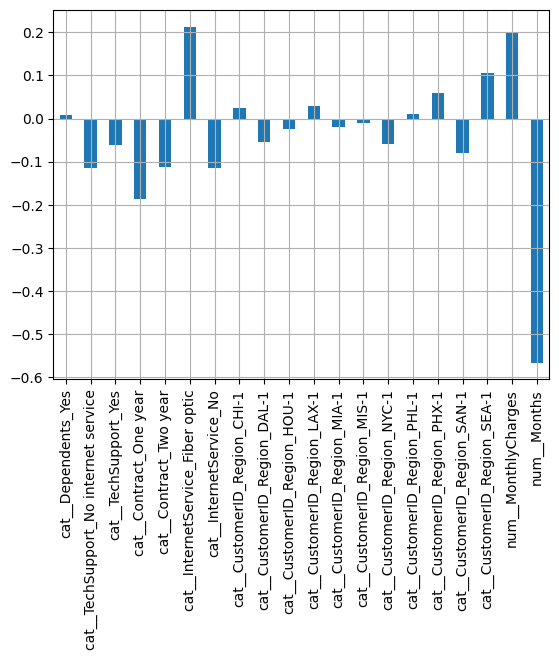

In [42]:
coef = pd.DataFrame(model.coef_, columns=column_names)
coef.T.plot(kind="bar", legend=False)
plt.grid()
plt.show()

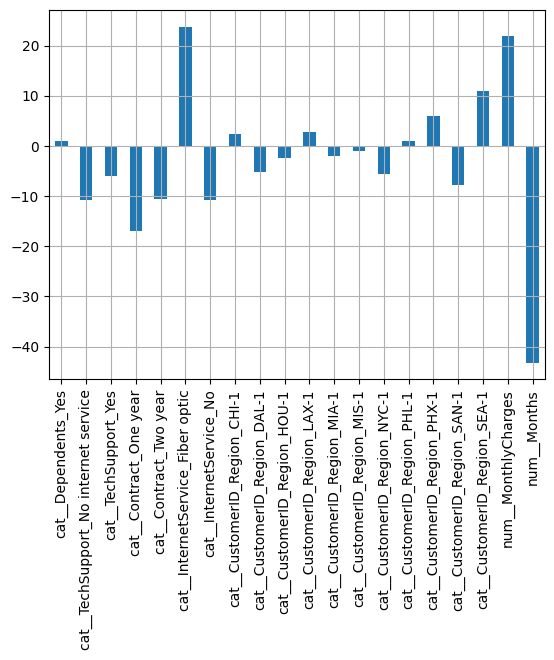

In [43]:
odds_changes = (np.exp(model.coef_) - 1) * 100
coef = pd.DataFrame(odds_changes, columns=column_names)
coef.T.plot(kind="bar", legend=False)
plt.grid()
plt.show()

In [44]:
X["Months"].std(), X["MonthlyCharges"].std()

(np.float64(23.61410818827673), np.float64(27.120965039260753))

These values are more reasonable ! We can see that the most impactful features are the contract type, months, the monthly charges, internetService with Fiber optic and the SEA-1 region: 1. the longer the subscription (contract type and months) the less likely the customer churns. 2. In particular, for each additional “months std” = 23.6 months -> -45% odds. 3. having a Fiber optic internet / high charges makes the customer more likely to churn 4. In particular, 26% higher odds of churning if the customer has fiber: it could perhaps more competitiveness between providers. 5. For each additional 27$ per month, the customer odds of churning increase by 23.65%. 6. Finally, being in SEA-1 increases the odds by 11%.

We can also try L1 regularization for sparse coefficients (feature selection):

In [45]:
model = LogisticRegressionCV(Cs=np.logspace(-4, 4, 100), penalty="l1", solver="liblinear")
model.fit(X_train_processed, y_train.values)

y_train_pred = model.predict(X_train_processed)
y_test_pred = model.predict(X_test_processed)

# Evaluate the model accuracy
print(f"Training accuracy: {accuracy_score(y_train_pred, y_train):.4f}")
print(f"Test accuracy: {accuracy_score(y_test_pred, y_test):.4f}")

C:\Users\EQUIPO\desktop\projects\bayessian\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
C:\Users\EQUIPO\desktop\projects\bayessian\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:2123: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' and 'Cs' instead. Use l1_ratios=(0,) instead of penalty='l2', l1_ratios=(1,) instead of penalty='l1', l1_ratios set to floats between 0 and 1 instead of penalty='elasticnet', and Cs=(np.inf,) instead of penalty=None.
  warnings.warn(
C:\Users\EQUIPO\desktop\projects\bayessian\venv\Lib\site-packages\sklearn\linear_model\_logistic.py

Training accuracy: 0.8429
Test accuracy: 0.6667


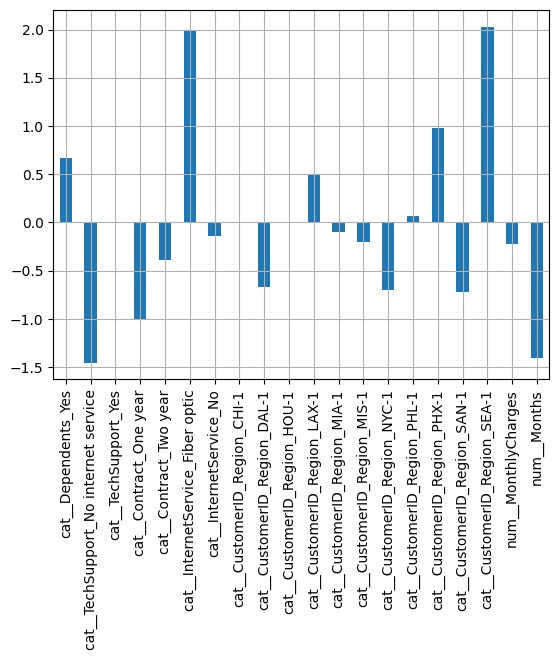

In [46]:
coef = pd.DataFrame(model.coef_, columns=column_names)
coef.T.plot(kind="bar", legend=False)
plt.grid()
plt.show()

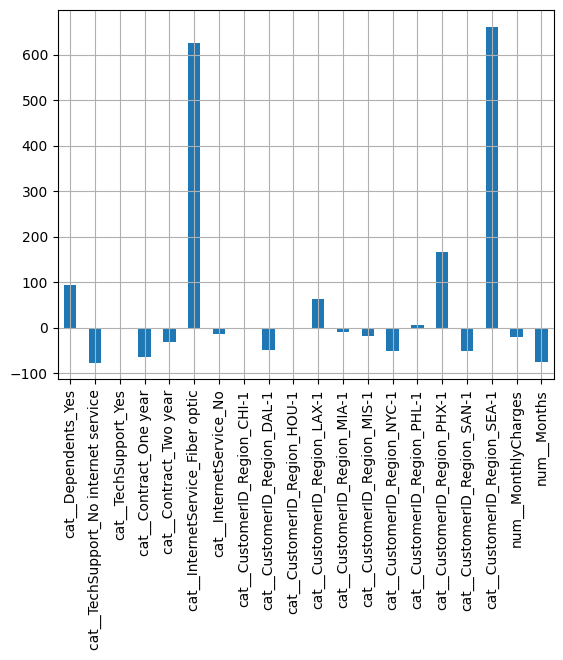

In [47]:
coef = pd.DataFrame(100 * (np.exp(model.coef_) - 1), columns=column_names)
coef.T.plot(kind="bar", legend=False)
plt.grid()
plt.show()

The model is similar to the unregularized case, we have 20 dimension with 100 observations: perhaps using feature selection is not a good idea here since the dimension is not that large compared to the number of observations: the Lasso keeps the largest coefficients and reduces the others to near 0.

With all these models, we can obtain the prediction probability (sigmoid) of 10 samples for e.g using:

In [48]:
model.predict_proba(X_test_processed[:10])

array([[0.22840727, 0.77159273],
       [0.29931356, 0.70068644],
       [0.22104899, 0.77895101],
       [0.45509402, 0.54490598],
       [0.28543635, 0.71456365],
       [0.85739397, 0.14260603],
       [0.67827306, 0.32172694],
       [0.91051323, 0.08948677],
       [0.78661058, 0.21338942],
       [0.50536971, 0.49463029]])

The sigmoid probability of the model corresponds to the second column of the output above.

It outputs a vector of probabilites that sums to 1. We get the prediction class using the argmax or comparing the second column to 0.5:

In [50]:
model.predict_proba(X_test_processed[:10]).argmax(axis=1)

array([1, 1, 1, 1, 1, 0, 0, 0, 0, 0])

In [51]:
(model.predict_proba(X_test_processed[:10])[:, 1] > 0.5).astype(int)

array([1, 1, 1, 1, 1, 0, 0, 0, 0, 0])

## 4. Bayesian logistic regression
We can now build a bayesian logistic regression with a Gaussian prior using pymc:

### 4.1 Fitting the model with MCMC


In [52]:
import pymc as pm
import arviz as az
import seaborn as sns

# Build the model
n_mcmc_samples = 1000
coords = dict(var_names=column_names)
with pm.Model(coords=coords) as logistic_model:
    # Priors for weights and intercept
    sigma = pm.HalfCauchy('sigma', beta=1)
    intercept = pm.Normal('intercept', mu=0, sigma=sigma)
    betas = pm.Normal('betas', mu=0, sigma=sigma, shape=X_train_processed.shape[1])
    
    # Linear predictor
    mu = pm.math.dot(X_train_processed, betas) + intercept
    
    # Likelihood (observed outcome)
    theta = pm.math.sigmoid(mu)
    y_obs = pm.Bernoulli('y_obs', p=theta, observed=y_train)
    
    # Sample from posterior
    trace = pm.sample(n_mcmc_samples, tune=1000, return_inferencedata=True)
az.summary(trace)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, intercept, betas]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept,-0.28,0.44,-0.99,0.4,2971,2568,1.00,0.0082,0.0068
betas[0],0.33,0.46,-0.4,1.1,3239,2469,1.00,0.0082,0.0062
betas[1],-0.52,0.71,-1.7,0.54,4065,2818,1.00,0.011,0.0096
betas[2],-0.07,0.45,-0.78,0.66,4527,2846,1.00,0.0066,0.005
betas[3],-0.83,0.54,-1.7,0.00038,4069,2960,1.00,0.0086,0.0061
betas[4],-0.36,0.62,-1.4,0.62,5138,3136,1.00,0.0087,0.0067
betas[5],1.01,0.61,0.12,2.1,2105,2562,1.00,0.013,0.01
betas[6],-0.52,0.71,-1.7,0.55,4428,2710,1.00,0.011,0.0098
betas[7],-0.06,0.65,-1.1,0.97,5315,2774,1.00,0.0089,0.0067
betas[8],-0.56,0.58,-1.5,0.32,3883,2564,1.00,0.0095,0.0075


No warnings, all rhats are equal to 1, the ESS are all very large, no red flags of divergences. the MCMC chains pass all diagnostics. To intepret the coefficients, we should check the HDI of the coefficients, if they contain 0 it means that 0 is included in the 94% credible interval: therefore the coefficient is not statistically different from 0:

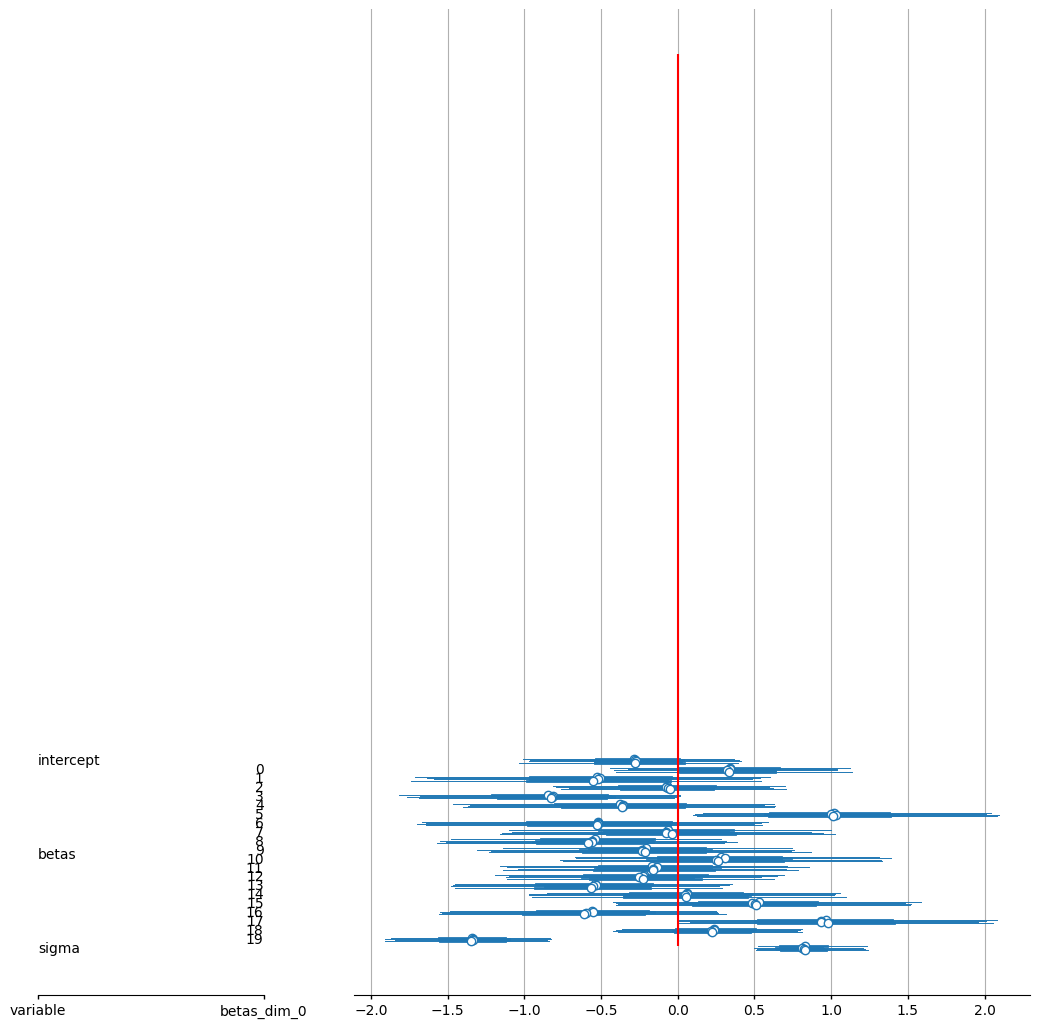

In [53]:
az.plot_forest(trace)
plt.grid()
plt.vlines(0, 0, ymax=100, color="red")
plt.show()

None of them are except sigma and beta[19] which corresponds to the last variable “Months”

In [54]:
column_names[19]

'num__Months'

In [55]:
100 * (np.exp(-1.352) - 1)

np.float64(-74.127770174036)

### 4.2 Making predictions
How do we make predictions with this model ? Well, we can use the MCMC samples (beta) to compute the sigmoid probabilities on the test data:

In [56]:
beta_samples = trace.posterior["betas"].values.reshape(-1, 20)
beta_samples.shape

(4000, 20)

In [57]:
intercept_samples = trace.posterior["intercept"].values.reshape(-1, 1)
intercept_samples.shape

(4000, 1)

In [58]:
from scipy.special import expit as sigmoid

def get_bayes_probas(X, trace):
    beta_samples = trace.posterior["betas"].values.reshape(-1, 20)
    # vector of size 4000 x 20
    intercept_samples = trace.posterior["intercept"].values.reshape(1, -1)
    # vector of size 4000 x 1

    # X test is of size n_samples x 20 so we transpose beta_samples to have a size 20 x 4000
    # then we transpose the output to be 4000 x n_samples compatible with intercept_samples of size 1 x 4000
    logits = X.dot(beta_samples.T) + intercept_samples
    # we have a vector of size n_samples x 4000
    return sigmoid(logits)

probas_bayes_train = get_bayes_probas(X_train_processed, trace)
probas_bayes_test = get_bayes_probas(X_test_processed, trace)

probas_bayes_train.shape, probas_bayes_test.shape

((140, 4000), (60, 4000))

We have 4000 different predictions for each of the 60 test samples, we can compute the average prediction and the standard deviation to evaluate our uncertainty:

In [59]:
mean_proba_bayes_train = probas_bayes_train.mean(axis=1)
std_proba_bayes_train = probas_bayes_train.std(axis=1)

mean_proba_bayes_test = probas_bayes_test.mean(axis=1)
std_proba_bayes_test = probas_bayes_test.std(axis=1)

bayes_predictions_train = (mean_proba_bayes_train > 0.5).astype(int)
bayes_predictions_test = (mean_proba_bayes_test > 0.5).astype(int)

print(f"Training accuracy: {accuracy_score(y_train, bayes_predictions_train):.4f}")
print(f"Test accuracy: {accuracy_score(y_test, bayes_predictions_test):.4f}")

Training accuracy: 0.8071
Test accuracy: 0.6833


It seems like the performance is similar or even a bit worse than the frequentist approach (Ridge). Why go through the trouble of MCMC then ? Well, because we can compute also uncertainties around those mean predictions of the MCMC samples. For example, with the frequentist approach we would get the the probability of churn is 0.8. With the bayesian approach we have 4000 probabilities of churn for each sample, assume their mean is identical: 0.8. With the 4000 MCMC samples we can also compute an HDI of those probabilities. If the HDI is too large say [0.3, 1.] then we cannot say for sure that 0.8 is statistically significant. If however the HDI is [0.7, 0.9] (it is far from 0.5) then we are more confident in our prediction.

In practice, the companies does not want to have many false positives (predict churn for customers who are actually satisfied and won’t leave) because it costs money (ads, promo deals to retain them…). So it might use the bayesian approach to only target the customers with predicted churn and high certainty. For the predicted churns with low certainty it may send them a satisfaction survey to be more certain.

## 5. How I manipulated the data
To illustrate the regularization here I truncated data to only 200 samples (from 10K samples in the kaggle dataset) and kept only a few variables otherwise MCMC would be too slow. And I also added fake variables: the region variable is purely random, completely unrelated to the churn variable. Yet, the regression (and Lasso) found a large coefficient for one of the regions ! This is to illustrate how models with little data can learn noise and lead to wrong intepretations of the coefficients: L2 regularization (and the bayesian approach however correctly reduced their amplitudes).

Let’s remove the region variable and see what happens. Before, we obtained with the unregularized model using the Regions:

.Training accuracy: 0.8357 \
.Test accuracy: 0.6500

In [60]:
categorical_features = ["Dependents", "TechSupport", "Contract", "InternetService"]
numeric_features = ["MonthlyCharges", "Months"]

categorical_transformer = OneHotEncoder(drop="first", sparse_output=False)
numeric_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features),
        ('num', numeric_transformer, numeric_features),
    ],
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

# we get the column names:
column_names = preprocessor.get_feature_names_out()

In [61]:
# we can fit the logistic regression model with no regularization:
model = LogisticRegression(penalty=None)
model.fit(X_train_processed, y_train.values)

y_train_pred = model.predict(X_train_processed)
y_test_pred = model.predict(X_test_processed)

# Evaluate the model accuracy
print(f"Training accuracy: {accuracy_score(y_train_pred, y_train):.4f}")
print(f"Test accuracy: {accuracy_score(y_test_pred, y_test):.4f}")

Training accuracy: 0.8214
Test accuracy: 0.6833


C:\Users\EQUIPO\desktop\projects\bayessian\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Slightly less train accuracy, more test accuracy: the model’s overfitting is reduced a little bit.